# Churn Prediction

## Business Problem

Customer churn leads to revenue loss and reduced customer lifetime value. Identifying customers who are likely to stop purchasing enables businesses to launch proactive retention campaigns and improve long-term profitability.

## Objective

Develop a machine learning pipeline that predicts customer churn using historical customer purchasing behavior and customer personas. The predicted churn probability will later be used for Customer Lifetime Value estimation, Revenue-at-Risk analysis, and AI-driven recommendation strategies.

In [35]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import joblib

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# Model Selection
from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

In [36]:
customer_df = pd.read_csv("../data/processed/customer_personas.csv")

future_df = pd.read_csv("../data/processed/future_transactions.csv")

In [37]:
customer_df.shape

(3365, 12)

In [38]:
customer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3365 entries, 0 to 3364
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           3365 non-null   float64
 1   Recency              3365 non-null   int64  
 2   Frequency            3365 non-null   int64  
 3   Monetary             3365 non-null   float64
 4   Average_Order_Value  3365 non-null   float64
 5   R_Score              3365 non-null   int64  
 6   F_Score              3365 non-null   int64  
 7   M_Score              3365 non-null   int64  
 8   RFM_Score            3365 non-null   int64  
 9   Segment              3365 non-null   str    
 10  Persona_ID           3365 non-null   int64  
 11  Customer_Persona     3365 non-null   str    
dtypes: float64(3), int64(7), str(2)
memory usage: 406.6 KB


In [39]:
customer_df.describe()

,CustomerID,Recency,Frequency,Monetary,Average_Order_Value,R_Score,F_Score,M_Score,RFM_Score,Persona_ID
count,3365.000000,3365.000000,3365.000000,3365.000000,3365.000000,3365.000000,3365.000000,3365.000000,3365.000000,3365.000000
mean,15274.942942,184.960178,3.529866,1613.288458,397.421001,3.015453,3.000000,3.000000,334.545319,1.282318
std,1726.349698,79.863689,5.780679,6149.992648,1423.570904,1.415390,1.414424,1.414424,150.393157,0.955583
min,12346.000000,91.000000,1.000000,2.900000,2.900000,1.000000,1.000000,1.000000,111.000000,0.000000
25%,13784.000000,116.000000,1.000000,263.920000,168.310000,2.000000,2.000000,2.000000,215.000000,0.000000
50%,15232.000000,164.000000,2.000000,563.630000,283.030000,3.000000,3.000000,3.000000,333.000000,2.000000
75%,16766.000000,241.000000,4.000000,1392.840000,412.650000,4.000000,4.000000,4.000000,454.000000,2.000000
max,18287.000000,373.000000,131.000000,178302.620000,77183.600000,5.000000,5.000000,5.000000,555.000000,2.000000


In [40]:
customer_df.isnull().sum()

CustomerID             0
Recency                0
Frequency              0
Monetary               0
Average_Order_Value    0
R_Score                0
F_Score                0
M_Score                0
RFM_Score              0
Segment                0
Persona_ID             0
Customer_Persona       0
dtype: int64

In [41]:
future_orders = (
    future_df
    .groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

future_orders.head()

CustomerID
12347.0    2
12348.0    1
12349.0    1
12352.0    3
12356.0    1
Name: InvoiceNo, dtype: int64

In [42]:
customer_df["Future_Orders"] = (
    customer_df["CustomerID"]
    .map(future_orders)
    .fillna(0)
)

customer_df.head()

,CustomerID,Recency,Frequency,Monetary,Average_Order_Value,R_Score,F_Score,M_Score,RFM_Score,Segment,Persona_ID,Customer_Persona,Future_Orders
0,12346.0,325,1,77183.60,77183.60,1,1,5,115,Lost Customers,1,Active Customers,0.0
1,12347.0,129,5,2790.86,558.17,4,4,5,445,Champions,2,VIP Customers,2.0
2,12348.0,248,3,1487.24,495.75,2,4,4,244,At Risk,0,Dormant Customers,1.0
3,12350.0,309,1,334.40,334.40,1,1,2,112,Lost Customers,0,Dormant Customers,0.0
4,12352.0,261,5,1561.81,312.36,2,4,4,244,At Risk,0,Dormant Customers,3.0


In [43]:
customer_df["Churn"] = (
    customer_df["Future_Orders"] == 0
).astype(int)

In [44]:
customer_df["Churn"].value_counts()

Churn
0    1920
1    1445
Name: count, dtype: int64

In [45]:
customer_df["Churn"].value_counts(normalize=True)*100

Churn
0    57.057949
1    42.942051
Name: proportion, dtype: float64

In [46]:
customer_df.drop(
    columns="Future_Orders",
    inplace=True
)

In [47]:
features = [

    "Recency",

    "Frequency",

    "Monetary",

    "Average_Order_Value",

    "Customer_Persona"

]

X = customer_df[features]

y = customer_df["Churn"]

In [48]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [49]:
numeric_features = [

    "Recency",

    "Frequency",

    "Monetary",

    "Average_Order_Value"

]

categorical_features = [

    "Customer_Persona"

]

In [50]:
preprocessor = ColumnTransformer(

    transformers=[

        (

            "num",

            StandardScaler(),

            numeric_features

        ),

        (

            "cat",

            OneHotEncoder(handle_unknown="ignore"),

            categorical_features

        )

    ]

)

In [51]:
models = {

    "Logistic Regression":

        LogisticRegression(

            max_iter=1000,

            random_state=42,

            class_weight="balanced"

        ),

    "Decision Tree":

        DecisionTreeClassifier(

            random_state=42,

            class_weight="balanced"

        ),

    "Random Forest":

        RandomForestClassifier(

            random_state=42,

            class_weight="balanced"

        ),

    "KNN":

        KNeighborsClassifier(),

    "SVC":

        SVC(

            probability=True,

            random_state=42

        ),

    "XGBoost":

        XGBClassifier(

            random_state=42,

            eval_metric="logloss"

        )

}

In [52]:
cv_results = []

In [53]:
for model_name, model in models.items():

    pipeline = Pipeline(

        steps=[

            ("preprocessor", preprocessor),

            ("model", model)

        ]

    )

    scores = cross_val_score(

        pipeline,

        X_train,

        y_train,

        cv=5,

        scoring="roc_auc",

        n_jobs=-1

    )

    cv_results.append({

        "Model": model_name,

        "Mean ROC_AUC": scores.mean(),

        "Std": scores.std()

    })

    print("="*60)

    print(model_name)

    print("Fold Scores :", scores)

    print(f"Mean ROC-AUC : {scores.mean():.4f}")

Logistic Regression
Fold Scores : [0.72460224 0.75480175 0.71713411 0.74336196 0.74795888]
Mean ROC-AUC : 0.7376
Decision Tree
Fold Scores : [0.59686147 0.60983657 0.60122397 0.57730868 0.59091614]
Mean ROC-AUC : 0.5952
Random Forest
Fold Scores : [0.67055996 0.69871813 0.69971234 0.6706361  0.70243383]
Mean ROC-AUC : 0.6884
KNN
Fold Scores : [0.67226064 0.69258256 0.68079586 0.67838459 0.68700735]
Mean ROC-AUC : 0.6822
SVC
Fold Scores : [0.71120762 0.73784118 0.7055995  0.72319754 0.7467462 ]
Mean ROC-AUC : 0.7249
XGBoost
Fold Scores : [0.69273908 0.70843395 0.70349846 0.65965142 0.70464769]
Mean ROC-AUC : 0.6938


In [54]:
cv_results = pd.DataFrame(cv_results)

cv_results.sort_values(

    by="Mean ROC_AUC",

    ascending=False,

    inplace=True

)

cv_results

,Model,Mean ROC_AUC,Std
0,Logistic Regression,0.737572,0.014312
4,SVC,0.724918,0.015541
5,XGBoost,0.693794,0.017850
2,Random Forest,0.688412,0.014596
3,KNN,0.682206,0.007018
1,Decision Tree,0.595229,0.010879


In [55]:
best_model_name = cv_results.iloc[0]["Model"]

best_model_name

'Logistic Regression'

In [56]:
best_model = models[best_model_name]

In [57]:
param_grids = {

    "Logistic Regression": {

        "model__C": [0.01, 0.1, 1, 10, 100]

    },

    "Decision Tree": {

        "model__criterion": ["gini", "entropy"],

        "model__max_depth": [3, 5, 10, 20, None],

        "model__min_samples_split": [2, 5, 10],

        "model__min_samples_leaf": [1, 2, 4]

    },

    "Random Forest": {

        "model__n_estimators": [100, 200, 300, 500],

        "model__max_depth": [5, 10, 20, None],

        "model__min_samples_split": [2, 5, 10],

        "model__min_samples_leaf": [1, 2, 4]

    },

    "KNN": {

        "model__n_neighbors": [3, 5, 7, 9, 11],

        "model__weights": ["uniform", "distance"]

    },

    "SVC": {

        "model__C": [0.1, 1, 10, 100],

        "model__kernel": ["linear", "rbf"],

        "model__gamma": ["scale", "auto"]

    },

    "XGBoost": {

        "model__n_estimators": [100, 200, 300],

        "model__learning_rate": [0.01, 0.05, 0.1, 0.3],

        "model__max_depth": [3, 5, 7],

        "model__subsample": [0.8, 1.0],

        "model__colsample_bytree": [0.8, 1.0]

    }

}

In [58]:
search_strategy = {

    "Logistic Regression": "grid",

    "Decision Tree": "grid",

    "KNN": "grid",

    "SVC": "grid",

    "Random Forest": "random",

    "XGBoost": "random"

}

In [59]:
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV
)

In [60]:
def tune_model(
    model_name,
    model,
    params,
    preprocessor,
    X_train,
    y_train
):

    pipeline = Pipeline([

        ("preprocessor", preprocessor),

        ("model", model)

    ])

    if search_strategy[model_name] == "grid":

        search = GridSearchCV(

            estimator=pipeline,

            param_grid=params,

            cv=5,

            scoring="roc_auc",

            n_jobs=-1

        )

    else:

        search = RandomizedSearchCV(

            estimator=pipeline,

            param_distributions=params,

            n_iter=20,

            cv=5,

            scoring="roc_auc",

            random_state=42,

            n_jobs=-1

        )

    search.fit(
        X_train,
        y_train
    )

    return search

In [61]:
best_models = {}

tuning_results = []

In [62]:
for model_name, model in models.items():

    print("=" * 70)

    print(f"Tuning {model_name}...")

    search = tune_model(

        model_name=model_name,

        model=model,

        params=param_grids[model_name],

        preprocessor=preprocessor,

        X_train=X_train,

        y_train=y_train

    )

    best_models[model_name] = search.best_estimator_

    tuning_results.append({

        "Model": model_name,

        "Best ROC_AUC": search.best_score_,

        "Best Parameters": search.best_params_

    })

    print("Best ROC-AUC :", round(search.best_score_,4))

    print()

    print(search.best_params_)

    print()

Tuning Logistic Regression...
Best ROC-AUC : 0.7378

{'model__C': 100}

Tuning Decision Tree...
Best ROC-AUC : 0.7272

{'model__criterion': 'entropy', 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}

Tuning Random Forest...
Best ROC-AUC : 0.7432

{'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': 5}

Tuning KNN...
Best ROC-AUC : 0.7042

{'model__n_neighbors': 11, 'model__weights': 'uniform'}

Tuning SVC...
Best ROC-AUC : 0.731

{'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}

Tuning XGBoost...
Best ROC-AUC : 0.7429

{'model__subsample': 1.0, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}



In [63]:
tuning_results = pd.DataFrame(
    tuning_results
)

tuning_results.sort_values(

    by="Best ROC_AUC",

    ascending=False,

    inplace=True

)

tuning_results

,Model,Best ROC_AUC,Best Parameters
2,Random Forest,0.743153,"{'model__n_estimators': 500, 'model__min_sampl..."
5,XGBoost,0.742874,"{'model__subsample': 1.0, 'model__n_estimators..."
0,Logistic Regression,0.737831,{'model__C': 100}
4,SVC,0.730954,"{'model__C': 0.1, 'model__gamma': 'scale', 'mo..."
1,Decision Tree,0.727230,"{'model__criterion': 'entropy', 'model__max_de..."
3,KNN,0.704229,"{'model__n_neighbors': 11, 'model__weights': '..."


In [64]:
best_model_name = tuning_results.iloc[0]["Model"]

print(best_model_name)

Random Forest


In [65]:
best_pipeline = best_models[best_model_name]

In [66]:
best_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['Recency','Frequency','Monetary','Average_Order_Value','Customer_Persona']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, al

In [67]:
y_pred = best_pipeline.predict(
    X_test
)

In [68]:
y_prob = best_pipeline.predict_proba(
    X_test
)[:,1]

In [69]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {

        "Accuracy": accuracy_score(y_test, y_pred),

        "Precision": precision_score(y_test, y_pred),

        "Recall": recall_score(y_test, y_pred),

        "F1 Score": f1_score(y_test, y_pred),

        "ROC-AUC": roc_auc_score(y_test, y_prob)

    }

    print("=" * 70)
    print("Model Evaluation")
    print("=" * 70)

    for metric, value in metrics.items():
        print(f"{metric:<15}: {value:.4f}")

    print("\nClassification Report\n")

    print(classification_report(y_test, y_pred))

    return metrics

In [70]:
metrics = evaluate_model(

    best_pipeline,

    X_test,

    y_test

)

Model Evaluation
Accuracy       : 0.6716
Precision      : 0.5890
Recall         : 0.7785
F1 Score       : 0.6706
ROC-AUC        : 0.7433

Classification Report

              precision    recall  f1-score   support

           0       0.78      0.59      0.67       384
           1       0.59      0.78      0.67       289

    accuracy                           0.67       673
   macro avg       0.68      0.68      0.67       673
weighted avg       0.70      0.67      0.67       673



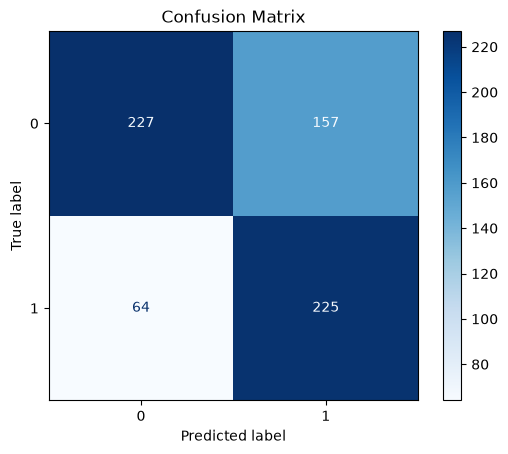

In [71]:
ConfusionMatrixDisplay.from_estimator(

    best_pipeline,

    X_test,

    y_test,

    cmap="Blues"

)

plt.title("Confusion Matrix")

plt.show()

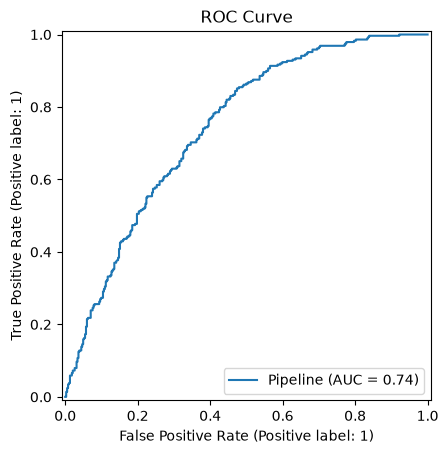

In [72]:
RocCurveDisplay.from_estimator(

    best_pipeline,

    X_test,

    y_test

)

plt.title("ROC Curve")

plt.show()

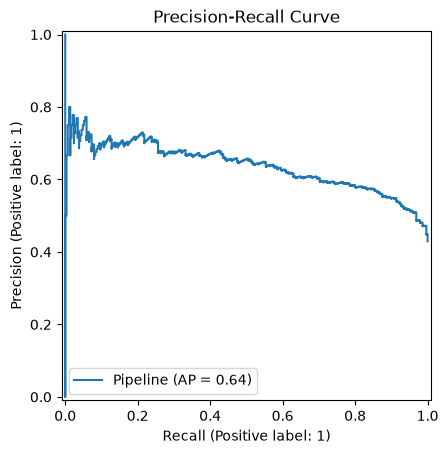

In [73]:
PrecisionRecallDisplay.from_estimator(

    best_pipeline,

    X_test,

    y_test

)

plt.title("Precision-Recall Curve")

plt.show()

In [74]:
comparison = []

In [75]:
for model_name, model in best_models.items():

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    comparison.append({

        "Model": model_name,

        "Accuracy": accuracy_score(y_test, y_pred),

        "Precision": precision_score(y_test, y_pred),

        "Recall": recall_score(y_test, y_pred),

        "F1 Score": f1_score(y_test, y_pred),

        "ROC-AUC": roc_auc_score(y_test, y_prob)

    })

In [76]:
comparison_df = pd.DataFrame(comparison)

comparison_df.sort_values(

    by="ROC-AUC",

    ascending=False,

    inplace=True

)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.671620,0.589005,0.778547,0.670641,0.743264
5,XGBoost,0.671620,0.611842,0.643599,0.627319,0.740759
1,Decision Tree,0.647845,0.559361,0.847751,0.674003,0.726891
0,Logistic Regression,0.667162,0.583548,0.785467,0.669617,0.725806
4,SVC,0.647845,0.604839,0.519031,0.558659,0.723724
3,KNN,0.643388,0.589744,0.557093,0.572954,0.709640


In [77]:
import joblib

joblib.dump(
    best_pipeline,
    "../models/churn_prediction_pipeline.pkl"
)

print("Pipeline Saved Successfully")

Pipeline Saved Successfully


In [78]:
loaded_pipeline = joblib.load(
    "../models/churn_prediction_pipeline.pkl"
)

loaded_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['Recency','Frequency','Monetary','Average_Order_Value','Customer_Persona']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, al

In [79]:
customer_df["Churn_Probability"] = best_pipeline.predict_proba(X)[:,1]

In [80]:
customer_df.head()

,CustomerID,Recency,Frequency,Monetary,Average_Order_Value,R_Score,F_Score,M_Score,RFM_Score,Segment,Persona_ID,Customer_Persona,Churn,Churn_Probability
0,12346.0,325,1,77183.60,77183.60,1,1,5,115,Lost Customers,1,Active Customers,1,0.638875
1,12347.0,129,5,2790.86,558.17,4,4,5,445,Champions,2,VIP Customers,0,0.147440
2,12348.0,248,3,1487.24,495.75,2,4,4,244,At Risk,0,Dormant Customers,0,0.438221
3,12350.0,309,1,334.40,334.40,1,1,2,112,Lost Customers,0,Dormant Customers,1,0.757244
4,12352.0,261,5,1561.81,312.36,2,4,4,244,At Risk,0,Dormant Customers,0,0.326208


In [81]:
customer_df.to_csv(
    "../data/processed/customer_churn_predictions.csv",
    index=False
)

# Business Insights

1. Random Forest achieved the highest predictive performance among all evaluated machine learning models after hyperparameter tuning and was selected as the final production model.

2. The model successfully identifies approximately 78% of customers who are likely to churn, enabling proactive customer retention campaigns.

3. Customer purchasing behavior, including Recency, Frequency, Monetary Value, Average Order Value, and Customer Persona, provides meaningful signals for predicting customer churn.

4. The leakage-free time-based modeling approach ensures that predictions are based exclusively on historical customer behavior, making the model suitable for real-world deployment.

5. Predicted churn probabilities will be used in subsequent Customer Lifetime Value (CLV) estimation, Revenue-at-Risk analysis, and AI Recommendation modules to support data-driven business decisions.

# Business Conclusion

A production-ready churn prediction pipeline was successfully developed using historical customer purchasing behavior and customer personas derived from RFM analysis. By separating the observation and prediction windows, the model avoids target leakage and produces realistic predictions suitable for operational use.

After evaluating six machine learning algorithms using standardized preprocessing, cross-validation, and hyperparameter tuning, Random Forest achieved the best overall performance and was selected as the final model. The trained pipeline enables businesses to identify customers at high risk of churn, support proactive retention strategies, and serve as the foundation for Customer Lifetime Value prediction, Revenue-at-Risk estimation, and AI-driven customer engagement.